# Analyse des tirs à 3 points réalisés par équipe de 1996 à 2020 en NBA

> _"Je déteste les données larges."_

Dans la continuité de mon [premier projet](https://github.com/ballagye/DataProjects/blob/main/notebooks/Project1.ipynb), nous repartons sur la tendance du tir à 3 points, cette fois-ci en collectant les données de l'ensemble des équipes de la ligue, pour les statistiques étudiées précédemment. Pour ce projet, j'ai choisi d'utiliser la bibliothèque [Polars](https://pola.rs/) au lieu de Pandas, car c'est une bibliothèque plus rapide en traitement de données, pouvant atteindre des performances jusqu'à 30 fois supérieures à Pandas, et je souhaitais expérimenter avec une nouvelle bibliothèque d'analyse de données.

Pour ce projet, j'ai utilisé le même dataset disponible sur [Kaggle](https://www.kaggle.com/datasets/mahendrakaswan/nba-3point-shooting-data-19962020), qui comprend les données des tirs à 3 points réalisés par équipe de **1996 à 2020**.

Les étapes clés de cette analyse :

- **Nettoyage des données**
- **Création d'une nouvelle DataFrame**
- **Visualisation des données**


Avant de traiter nos données, j'ai importé les bibliothèques nécessaires afin d'interagir avec nos données. Cette fois-ci, j'ai utilisé Polars


In [112]:
import polars as pl  # Manipuler les données du dataset
import matplotlib.pyplot as plt  # Visualiser les données


### 2. Traitement

Les données sont toujours au format Excel. Elles ont été converties au format CSV mais cette fois-ci sur une autre feuille de l'Excel qui contient toutes les données que l'on va utiliser.


In [113]:
df = pl.read_csv("../data/NBA_DATASET/shootingdataperteam.csv")

#### Voici la DataFrame initiale :


In [114]:
print(df)

shape: (37, 98)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│           ┆ Unnamed:  ┆ Unnamed:  ┆ Unnamed:  ┆ … ┆ Unnamed:  ┆ Unnamed:  ┆ Unnamed:  ┆ Unnamed: │
│ ---       ┆ 0         ┆ 2         ┆ 3         ┆   ┆ 94        ┆ 95        ┆ 96        ┆ 97       │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ str       ┆ str       ┆ str       ┆   ┆ str       ┆ str       ┆ str       ┆ str      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ null      ┆ null      ┆ null      ┆ null      ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
│ Yearwise  ┆ null      ┆ null      ┆ null      ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
│ Data      ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ null      ┆ null      ┆ null      ┆ null      ┆ … ┆ null      ┆ null     

Afin de nettoyer la DataFrame, j'ai commencé par supprimer la deuxième colonne nulle et j'ai séparé les données en plusieurs variables : une pour les années, une pour les équipes de la ligue et une par statistique.

J'ai retenu 3 statistiques pour ce projet : les 3 points réalisés, les tentatives de 3 points et le pourcentage de réussite à 3 points.


In [115]:
df = df.drop("Unnamed: 0")

years = df[3, 1::4]
teams = df[5:35, 0]

threePointsMade = df[5:35, 1::4]
threePointsAttempts = df[5:35, 2::4]
threePointsPercent = df[5:35, 3::4]

Lors de la création des variables, j'ai remarqué que le dataset suivait un pattern spécifique : toutes les 4 colonnes, on retrouvait dans l'ordre les 3 points réalisés (3PM), les tentatives de 3 points (3PA) et le pourcentage de réussite (3P%) pour une équipe et une année donnée. C'est ce pattern qui justifie le slicing avec un pas de 4 (`1::4`, `2::4`, `3::4`).

Voici les variables extraites :


In [116]:
print(years)
print(teams)
print(threePointsMade)
print(threePointsAttempts)
print(threePointsPercent)

shape: (1, 24)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Unnamed:  ┆ Unnamed:  ┆ Unnamed:  ┆ Unnamed:  ┆ … ┆ Unnamed:  ┆ Unnamed:  ┆ Unnamed:  ┆ Unnamed: │
│ 2         ┆ 6         ┆ 10        ┆ 14        ┆   ┆ 82        ┆ 86        ┆ 90        ┆ 94       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ str       ┆ str       ┆ str       ┆   ┆ str       ┆ str       ┆ str       ┆ str      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1996-97   ┆ 1997-98   ┆ 1998-99   ┆ 1999-00   ┆ … ┆ 2016-17   ┆ 2017-18   ┆ 2018-19   ┆ 2019-20  │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘
shape: (30,)
Series: '' [str]
[
	"Atlanta Hawks"
	"Boston Celtics"
	"Brooklyn Nets"
	"Chicago Bulls"
	"Cleveland Cavaliers"
	…
	"Toronto Raptors"
	"Utah Jazz"
	"Washington Wizar

Pour des raisons de facilité, j'ai converti les variables en numpy afin de les intégrer plus tard dans une nouvelle DataFrame, mieux adaptée à la visualisation et au traitement des données.


In [117]:
years = years.to_numpy()
years = years.flatten() # Pour la création de la DataFrame
teams = teams.to_numpy()
threePointsMade = threePointsMade.to_numpy()
threePointsAttempts = threePointsAttempts.to_numpy()
threePointsPercent = threePointsPercent.to_numpy()

#### 2.1. Création de la DataFrame et traitement


Après conversion, j'ai créé une nouvelle DataFrame contenant les équipes et leurs statistiques respectives par année, avec les colonnes suivantes : `Teams`, `3PM`, `3PA` et `3P%`.


In [118]:
new_df = pl.DataFrame({
    "Teams": teams,
    "3PA": threePointsAttempts,
    "3PM":  threePointsMade,
    "3P%": threePointsPercent
})

Cette partie est un peu plus technique. Afin de préparer les données pour la visualisation, j'ai utilisé la fonction `explode()` sur les colonnes `3PM`, `3PA` et `3P%`. En effet, suite à la conversion en numpy, ces colonnes contenaient des arrays un par année pour chaque équipe :

Démonstration :


In [119]:
print(threePointsMade)

[['8' '4.1' '3.9' '3.1' '4.5' '5.2' '4.9' '5.1' '3.7' '5.2' '4.2' '4.7'
  '7.3' '6.4' '6.1' '7.5' '8.6' '9.4' '10' '9.9' '8.9' '11.2' '13' '12']
 ['5.7' '5.1' '5.5' '5.1' '4.4' '8.5' '8.8' '6.7' '5.3' '5.7' '5.7' '7.3'
  '6.6' '6.1' '5' '5.5' '6.1' '7' '8' '8.7' '12' '11.5' '12.6' '12.6']
 ['5.9' '3.8' '4.5' '5.8' '4.8' '4.9' '4.2' '4.6' '5.3' '5.8' '7.4' '6.1'
  '8' '4.6' '5.6' '7.7' '7.7' '8.6' '5' '5.5' '7.3' '8' '10.1' '13.3']
 ['6.4' '3.8' '3.5' '4.1' '7.2' '3.7' '4.3' '5.2' '6.2' '6.8' '5.9' '5.8'
  '6' '4.3' '6.2' '6.3' '5.4' '6.2' '6.1' '10.6' '10' '10' '11.9' '12.1']
 ['5.9' '3.6' '3.6' '4.2' '4' '4.7' '3.6' '3' '3.7' '6.1' '6' '6.7' '8'
  '7.3' '6.2' '6.7' '6.7' '7.1' '7.9' '7.9' '7.6' '11' '9.1' '12.2']
 ['5.2' '5.1' '4' '6.3' '6.2' '7.6' '7.8' '6.2' '5.6' '5.1' '6.5' '6' '7'
  '6.8' '7.9' '7.5' '7.4' '8.8' '10.1' '10.7' '13' '12' '10.3' '11.2']
 ['7.8' '3.5' '6' '5.7' '4.4' '5.2' '2.8' '4' '3.9' '4.3' '5.9' '6.9'
  '6.7' '6.6' '8.1' '6.6' '6.4' '8.6' '8.9' '9.8' '10.7' '11.

La fonction `explode()` permet de dérouler ces arrays afin d'obtenir une ligne par équipe par année, passant ainsi à un format long, mieux adapté à la visualisation.


In [120]:
new_df = new_df.explode("3PM","3PA","3P%")
print(new_df)

shape: (720, 4)
┌──────────────────────┬──────┬──────┬──────┐
│ Teams                ┆ 3PA  ┆ 3PM  ┆ 3P%  │
│ ---                  ┆ ---  ┆ ---  ┆ ---  │
│ str                  ┆ str  ┆ str  ┆ str  │
╞══════════════════════╪══════╪══════╪══════╡
│ Atlanta Hawks        ┆ 22.4 ┆ 8    ┆ 36   │
│ Atlanta Hawks        ┆ 12.4 ┆ 4.1  ┆ 33.2 │
│ Atlanta Hawks        ┆ 12.9 ┆ 3.9  ┆ 30.6 │
│ Atlanta Hawks        ┆ 9.9  ┆ 3.1  ┆ 31.7 │
│ Atlanta Hawks        ┆ 12.9 ┆ 4.5  ┆ 34.9 │
│ …                    ┆ …    ┆ …    ┆ …    │
│ New Orleans Pelicans ┆ 23.8 ┆ 8.6  ┆ 36   │
│ New Orleans Pelicans ┆ 26.8 ┆ 9.4  ┆ 35   │
│ New Orleans Pelicans ┆ 28.2 ┆ 10.2 ┆ 36.2 │
│ New Orleans Pelicans ┆ 29.9 ┆ 10.3 ┆ 34.4 │
│ New Orleans Pelicans ┆ 36.9 ┆ 13.6 ┆ 37   │
└──────────────────────┴──────┴──────┴──────┘


Après l'utilisation de `explode`, les données sont désormais organisées par année pour chaque équipe, ce qui nous permettra de les traiter et de les visualiser. Or, comme on peut le voir dans la DataFrame, les données sont de type `str`, il faut donc les convertir en `float` afin que Matplotlib puisse les afficher correctement.


In [121]:
new_df = new_df.with_columns(
    pl.col("3PM","3PA","3P%").cast(pl.Float64, strict=False)
)

### 3. Visualisation

On passe maintenant à la partie la plus intéressante : **la visualisation des données**. Après notre périple en traitant les données et en créant une nouvelle DataFrame, on va enfin pouvoir visualiser les tendances des tirs à 3 points par équipe en NBA. Pour cela, j'ai utilisé Matplotlib en réalisant 3 plots, un pour chaque statistique.


**Nous y sommes**. On va enfin pouvoir consulter les données par équipe, des tirs à 3 points, et voir réellement cette tendance que j'ai pu observer au cours des années ! J'ai effectué ma propre color map, essayez donc de trouver votre équipe favorite !


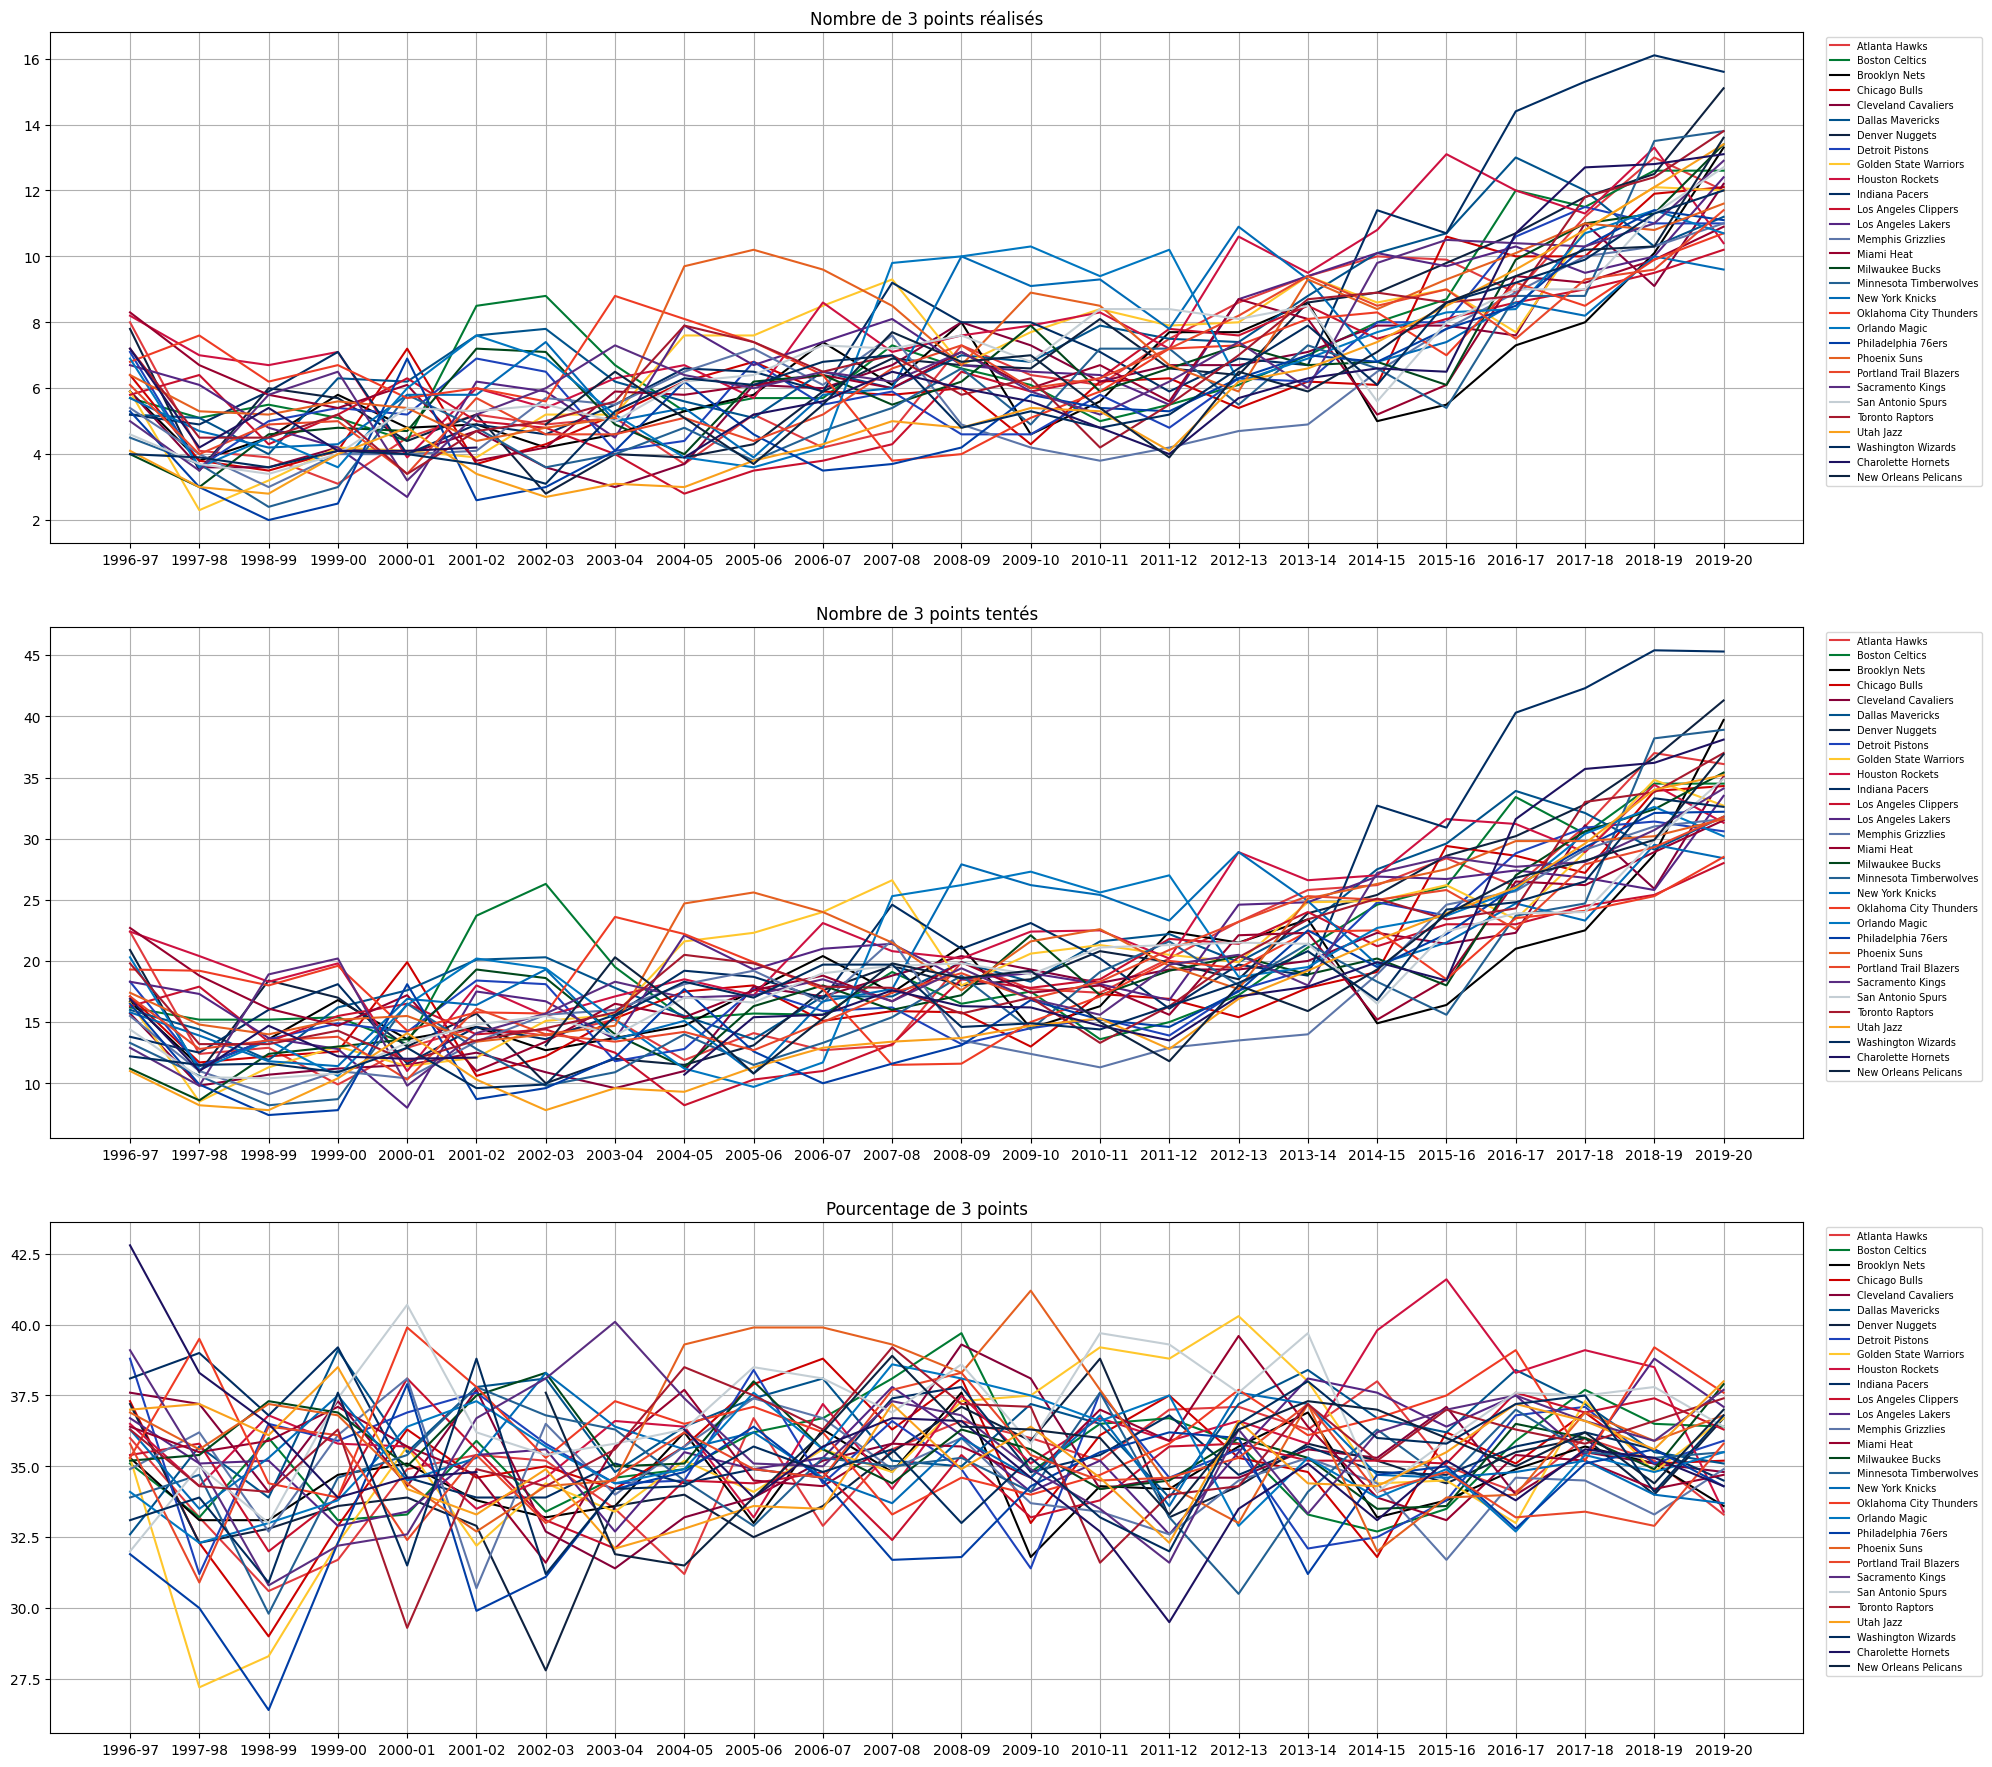

In [ ]:
colors = ["#E03A3E", "#007A33", "#000000", "#CC0000", "#860038", "#00538C", "#0E2240", "#1D42BA", "#1D428A", "#CE1141", "#002D62", "#C8102E", "#552583", "#5D76A9", "#98002E", "#00471B", "#236192", "#006BB6", "#EF3B24", "#0077C0", "#003DA5", "#E56020", "#E8472A", "#5A2D81", "#C4CED4", "#A6192E", "#F9A01B", "#002B5C", "#1D1160", "#0C2340"]

teams_ordered = teams.flatten().tolist()
color_map = {team: colors[i] for i, team in enumerate(teams_ordered)}

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 18))

for team in teams_ordered:
    team_data = new_df.filter(pl.col("Teams") == team)
    c = color_map[team]
    ax1.plot(years, team_data["3PM"], color=c, label=team)
    ax2.plot(years, team_data["3PA"], color=c, label=team)
    ax3.plot(years, team_data["3P%"], color=c, label=team)

ax1.set_title("Nombre de 3 points réalisés")
ax2.set_title("Nombre de 3 points tentés")
ax3.set_title("Pourcentage de 3 points")

ax1.grid(True)
ax2.grid(True)
ax3.grid(True)

ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
ax3.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

Tadam ! Alors, ce projet a été vraiment compliqué, dans le sens où c'était surtout le dataset qui était au format large au lieu d'être habituellement au format long, ce qui a rendu le traitement des données particulièrement difficile. Il faut souligner le nombre de données qui ont été traitées et visualisées : on parle d'un dataset de 720 lignes, et donc je suis très heureux du résultat.

Or, si je pouvais m'améliorer, ce serait surtout sur la partie visualisation, car les différentes courbes pour chaque équipe sont vraiment empaquetées. C'est pas terrible. J'aurais également aimé afficher les données par équipe, avec un script permettant de récupérer les données d'une seule équipe et d'afficher le plot correspondant. Je suis globalement assez content, et j'ai pu voir les fameux Golden State Warriors, qui tirent depuis des années plus que toute la NBA la croissance est bien visible sur les graphiques.

Je vous remercie de votre lecture,

Balla Gueye
